# Panel de ventas y logística — Olist (marketplace estilo Amazon)

**Pregunta de negocio:** ¿qué categorías, estados y vendedores impulsan más las ventas,
y dónde falla la logística (entregas tarde)?

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — ~99.000 pedidos de un marketplace real en Brasil (2016-2018), estructura muy parecida a la de Amazon (múltiples vendedores, productos, entregas, reseñas).

**Autor:** Alberto · proyecto 1 del portafolio (retail / e-commerce)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

RAW = "../data/raw"
PROCESSED = "../data/processed"

## 1. Carga de datos crudos

In [4]:
orders = pd.read_csv(f"{RAW}/olist_orders_dataset.csv")
items = pd.read_csv(f"{RAW}/olist_order_items_dataset.csv")
customers = pd.read_csv(f"{RAW}/olist_customers_dataset.csv")
products = pd.read_csv(f"{RAW}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{RAW}/olist_sellers_dataset.csv")
payments = pd.read_csv(f"{RAW}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{RAW}/olist_order_reviews_dataset.csv")
cat_translation = pd.read_csv(f"{RAW}/product_category_name_translation.csv")

for name, df in [("orders", orders), ("items", items), ("customers", customers),
                  ("products", products), ("sellers", sellers), ("payments", payments),
                  ("reviews", reviews)]:
    print(f"{name:10s} -> {df.shape[0]:,} filas, {df.shape[1]} columnas")

orders     -> 99,441 filas, 8 columnas
items      -> 112,650 filas, 7 columnas
customers  -> 99,441 filas, 5 columnas
products   -> 32,951 filas, 9 columnas
sellers    -> 3,095 filas, 4 columnas
payments   -> 103,886 filas, 5 columnas
reviews    -> 99,224 filas, 7 columnas


## 2. Limpieza

- Parseamos las fechas de pedido, entrega y entrega estimada.
- Nos quedamos con pedidos **entregados** para medir logística (no tiene sentido medir retraso de un pedido cancelado).
- Traducimos la categoría de producto al inglés (el dataset viene en portugués).
- Agregamos pagos y reseñas a nivel de pedido (un pedido puede tener varias filas de pago en cuotas, o alguna reseña duplicada).


In [6]:
date_cols = [
    "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date",
]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

print("Estados de pedido:")
print(orders["order_status"].value_counts())
print()
print("Rango de fechas de compra:", orders["order_purchase_timestamp"].min(), "->", orders["order_purchase_timestamp"].max())

Estados de pedido:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Rango de fechas de compra: 2016-09-04 21:15:19 -> 2018-10-17 17:30:18


In [7]:
delivered = orders[orders["order_status"] == "delivered"].copy()
delivered["delivery_days"] = (delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days
delivered["delay_days"] = (delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]).dt.days
delivered["on_time"] = delivered["delay_days"] <= 0

n_missing_dates = delivered["delivery_days"].isna().sum()
print(f"Pedidos 'delivered': {len(delivered):,}  ({n_missing_dates} sin fecha de entrega registrada, se descartan de las métricas de logística)")
delivered = delivered.dropna(subset=["delivery_days", "delay_days"])

Pedidos 'delivered': 96,478  (8 sin fecha de entrega registrada, se descartan de las métricas de logística)


In [8]:
products_en = products.merge(cat_translation, on="product_category_name", how="left")
products_en["product_category_name_english"] = (
    products_en["product_category_name_english"].fillna(products_en["product_category_name"])
)

payments_agg = payments.groupby("order_id", as_index=False).agg(
    payment_value_total=("payment_value", "sum"),
    payment_installments_max=("payment_installments", "max"),
    payment_type_main=("payment_type", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan),
)

reviews_agg = reviews.groupby("order_id", as_index=False).agg(review_score=("review_score", "mean"))

print("Tablas auxiliares listas:", products_en.shape, payments_agg.shape, reviews_agg.shape)

Tablas auxiliares listas: (32951, 10) (99440, 4) (98673, 2)


## 3. Tabla de ventas (grano: línea de pedido)

Unimos pedidos entregados + sus líneas de producto (`order_items`) + cliente + producto + vendedor
+ pagos + reseña. Esta es la tabla que alimentará las consultas SQL y el dashboard de Power BI.


In [10]:
ventas = (
    items.merge(delivered, on="order_id", how="inner")
         .merge(customers, on="customer_id", how="left")
         .merge(products_en, on="product_id", how="left")
         .merge(sellers, on="seller_id", how="left")
         .merge(payments_agg, on="order_id", how="left")
         .merge(reviews_agg, on="order_id", how="left")
)

ventas["revenue"] = ventas["price"] + ventas["freight_value"]
ventas["order_purchase_month"] = ventas["order_purchase_timestamp"].dt.to_period("M").astype(str)

cols = [
    "order_id", "order_item_id", "order_purchase_timestamp", "order_purchase_month",
    "customer_state", "customer_city", "seller_state", "product_category_name_english",
    "price", "freight_value", "revenue", "delivery_days", "delay_days", "on_time",
    "payment_type_main", "payment_installments_max", "review_score",
]
ventas = ventas[cols]
print(f"Tabla de ventas final: {ventas.shape[0]:,} líneas de pedido, {ventas.shape[1]} columnas")
ventas.head(3)

Tabla de ventas final: 110,189 líneas de pedido, 17 columnas


In [11]:
import os
os.makedirs(PROCESSED, exist_ok=True)
ventas.to_csv(f"{PROCESSED}/ventas_clean.csv", index=False)
print("Guardado en data/processed/ventas_clean.csv")

Guardado en data/processed/ventas_clean.csv


## 4. Insights: ¿qué mueve las ventas?

In [13]:
kpi_revenue = ventas["revenue"].sum()
kpi_orders = ventas["order_id"].nunique()
kpi_aov = ventas.groupby("order_id")["revenue"].sum().mean()
kpi_on_time = ventas.drop_duplicates("order_id")["on_time"].mean()
kpi_review = ventas.drop_duplicates("order_id")["review_score"].mean()

print(f"Ingresos totales (2016-2018):     R$ {kpi_revenue:,.0f}")
print(f"Pedidos entregados:                {kpi_orders:,}")
print(f"Ticket medio por pedido:           R$ {kpi_aov:,.2f}")
print(f"% de pedidos entregados a tiempo:  {kpi_on_time:.1%}")
print(f"Puntuación media de reseña:        {kpi_review:.2f} / 5")

Ingresos totales (2016-2018):     R$ 15,418,395
Pedidos entregados:                96,470
Ticket medio por pedido:           R$ 159.83
% de pedidos entregados a tiempo:  93.2%
Puntuación media de reseña:        4.16 / 5


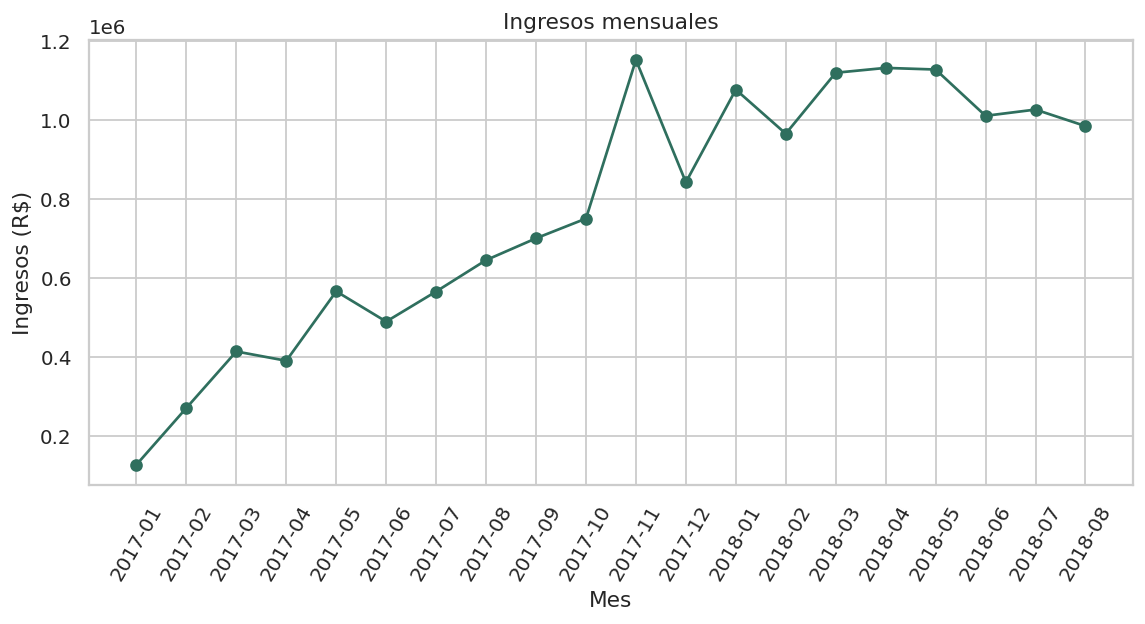

In [14]:
monthly = ventas.groupby("order_purchase_month", as_index=False)["revenue"].sum()
monthly = monthly[(monthly["order_purchase_month"] >= "2017-01") & (monthly["order_purchase_month"] <= "2018-08")]

fig, ax = plt.subplots()
ax.plot(monthly["order_purchase_month"], monthly["revenue"], marker="o", color="#2F6F5E")
ax.set_title("Ingresos mensuales")
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos (R$)")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

product_category_name_english
health_beauty            1412089.53
watches_gifts            1264016.98
bed_bath_table           1225209.26
sports_leisure           1118062.91
computers_accessories    1032603.65
furniture_decor           880329.92
housewares                758392.25
cool_stuff                691680.89
auto                      669319.92
garden_tools              567145.68
Name: revenue, dtype: float64


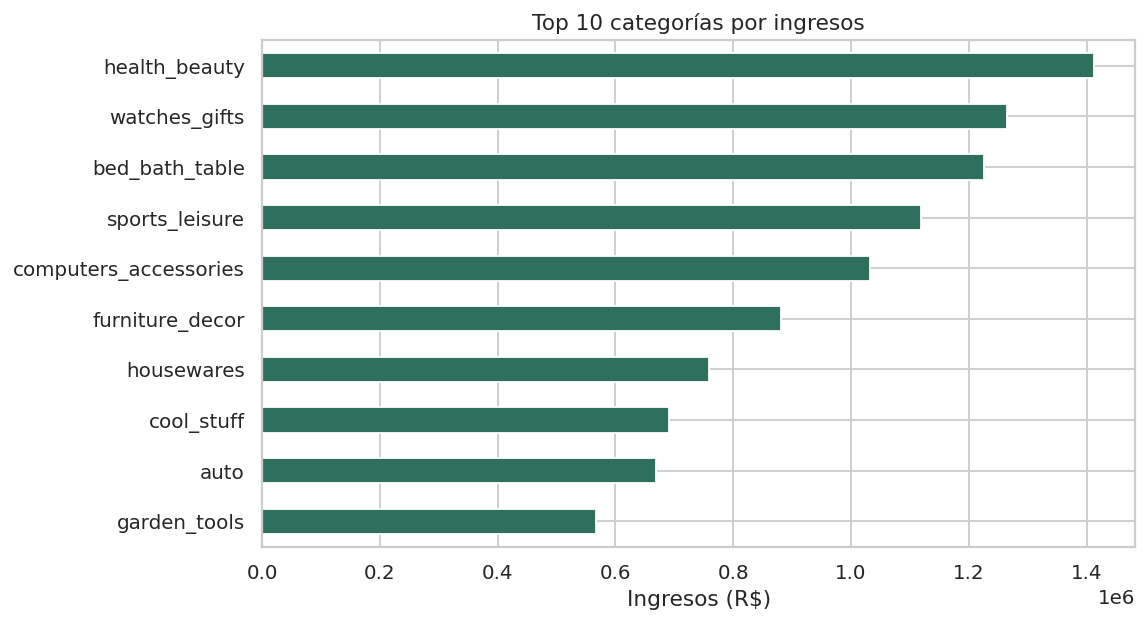

In [15]:
top_cat = (ventas.groupby("product_category_name_english")["revenue"]
                  .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots()
top_cat.sort_values().plot(kind="barh", ax=ax, color="#2F6F5E")
ax.set_title("Top 10 categorías por ingresos")
ax.set_xlabel("Ingresos (R$)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(top_cat)

customer_state
SP    5768518.23
RJ    2055401.57
MG    1818891.67
RS     861278.79
PR     781708.80
SC     595127.78
BA     591137.81
DF     346123.35
GO     334212.35
ES     317657.93
Name: revenue, dtype: float64


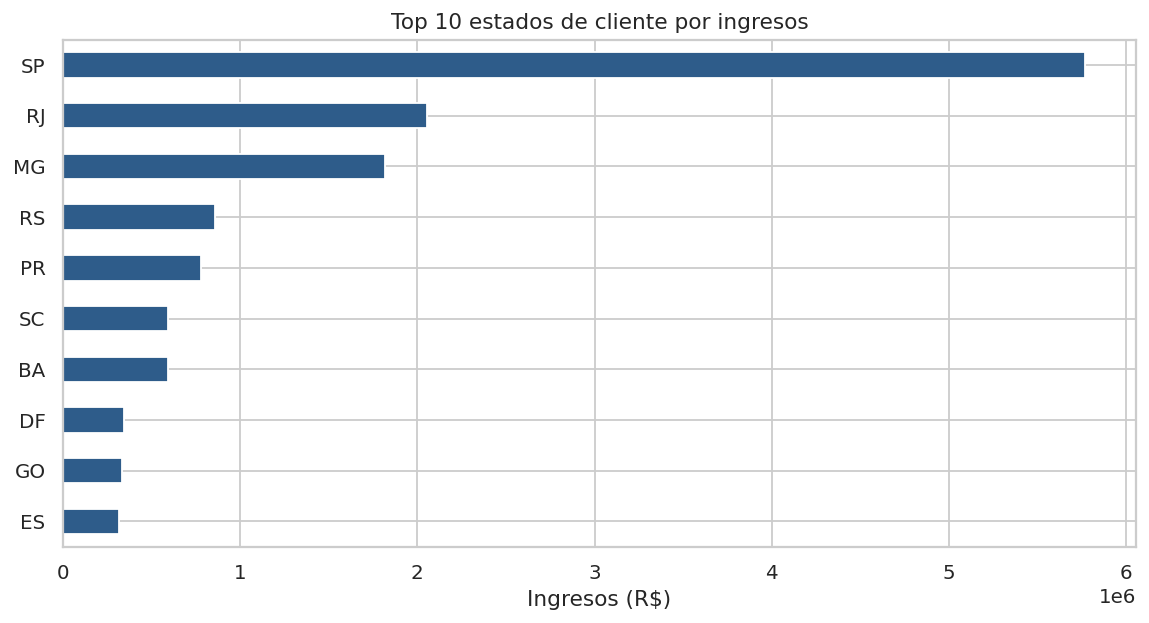

In [16]:
top_state = (ventas.groupby("customer_state")["revenue"]
                    .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots()
top_state.sort_values().plot(kind="barh", ax=ax, color="#2E5C8A")
ax.set_title("Top 10 estados de cliente por ingresos")
ax.set_xlabel("Ingresos (R$)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(top_state)

                pedidos  on_time_rate
customer_state                       
AL                  397      0.785894
MA                  717      0.825662
SE                  335      0.847761
PI                  476      0.861345
CE                 1279      0.862392
BA                 3256      0.878378
RJ                12350      0.878947
PA                  946      0.887949
ES                 1995      0.892732
PB                  517      0.895551


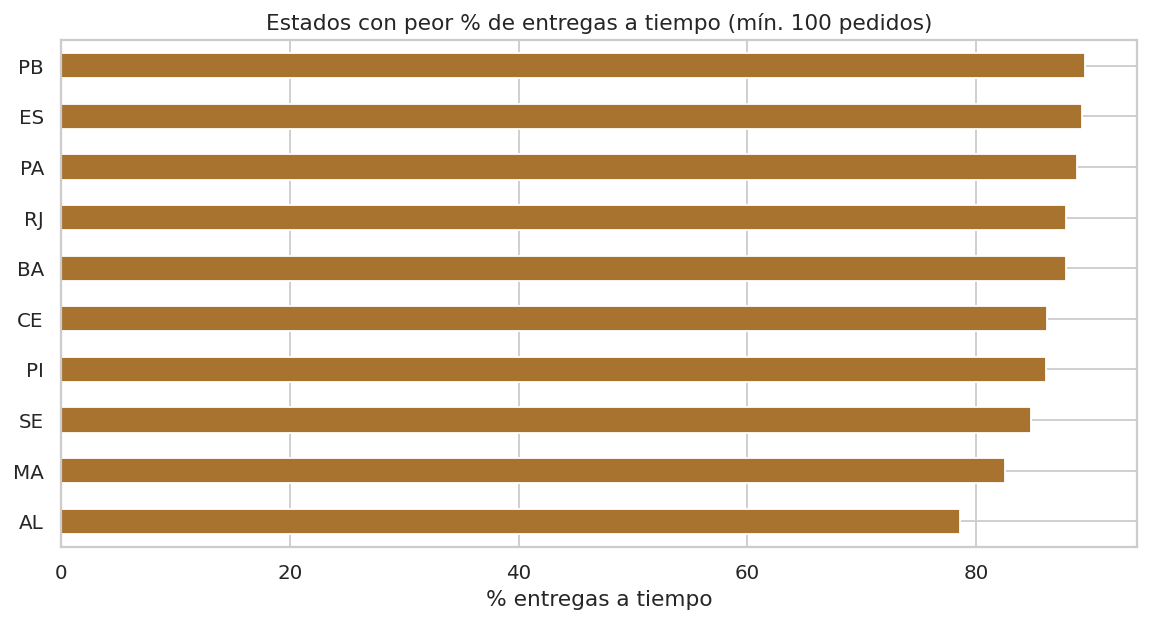

In [17]:
delay_by_state = (ventas.drop_duplicates("order_id")
                         .groupby("customer_state")
                         .agg(pedidos=("order_id", "nunique"), on_time_rate=("on_time", "mean"))
                         .query("pedidos >= 100")
                         .sort_values("on_time_rate")
                         .head(10))

fig, ax = plt.subplots()
(delay_by_state["on_time_rate"] * 100).sort_values().plot(kind="barh", ax=ax, color="#A8722F")
ax.set_title("Estados con peor % de entregas a tiempo (mín. 100 pedidos)")
ax.set_xlabel("% entregas a tiempo")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(delay_by_state)

## 5. Conclusiones

1. **Concentración geográfica:** São Paulo (SP) domina tanto en volumen de clientes como en
   ingresos — cualquier estrategia de stock/logística debería priorizar esa región.
2. **Categorías top:** un puñado de categorías (mobiliario/decoración, belleza, informática) concentran
   buena parte de los ingresos — candidatas claras para negociar mejores condiciones con esos vendedores.
3. **Logística como punto de dolor:** el % de entregas a tiempo varía bastante por estado — los estados
   más alejados del sudeste (norte/noreste de Brasil) tienen las peores tasas de entrega a tiempo, lo que
   probablemente explica parte de las reseñas bajas en esas zonas.

Siguiente paso del proyecto: las mismas preguntas resueltas con SQL (`sql/consultas.sql`) y un dashboard
interactivo en Power BI sobre `data/processed/ventas_clean.csv`.
